In [ ]:
%pip install puremacro


# Unit roots with power — DF-GLS vs ADF

**Is US real output trend-stationary or a random walk with drift?** The
question is a half-century old (Nelson & Plosser 1982) and it *hinges on a
test*: run the augmented Dickey-Fuller test on log real GDP and you cannot
reject a unit root, so output looks I(1) — shocks are permanent. But the ADF
test is notoriously **low-powered** near the unit root: when the largest root
is $0.95$ rather than $1$, ADF rejects far too rarely to tell the two apart.
Elliott, Rothenberg & Stock (1996, *Econometrica*) fixed this by replacing
OLS detrending with **GLS local-to-unity detrending**, squeezing out close to
the highest power any unit-root test can have. This notebook runs
`puremacro.tests.unit_root.dfgls_test` and `ng_perron_test` against plain
`adf_test` on frozen US macro data and shows the power gap is not a textbook
curiosity: on 1889-2015 log real GDP, **DF-GLS rejects the unit root where ADF
cannot** — and a Monte Carlo makes the extra power explicit.

## Why GLS detrending buys power

The augmented Dickey-Fuller regression tests $H_0:\rho=0$ (unit root) in
$$ \Delta y_t = \mu + \beta t + \rho\, y_{t-1} + \textstyle\sum_{j=1}^{k}\gamma_j \Delta y_{t-j} + \varepsilon_t. $$
Its weakness is the deterministic part: OLS estimates $(\mu,\beta)$ *jointly*
with $\rho$, and near $\rho=0$ that joint fit soaks up variation that should
have gone to the test. ERS instead **detrend first, by GLS at a local
alternative** $\bar\alpha = 1 + \bar c/T$ (with $\bar c=-7$ for a constant,
$\bar c=-13.5$ for a trend). Quasi-difference $y$ and the regressors
$z_t$ ($z_t=1$, or $z_t=(1,t)$),
$$ \tilde y_t = y_t - \bar\alpha\, y_{t-1},\qquad \tilde z_t = z_t - \bar\alpha\, z_{t-1}, $$
regress $\tilde y$ on $\tilde z$ to get $\hat\psi$, and form the detrended
series $y^d_t = y_t - z_t'\hat\psi$. The DF-GLS statistic is then the ordinary
$t$-ratio on $\rho$ in a DF regression on $y^d$ **with no intercept or trend**:
$$ \Delta y^d_t = \rho\, y^d_{t-1} + \textstyle\sum_{j=1}^{k}\gamma_j \Delta y^d_{t-j} + e_t. $$
Because the deterministic terms are removed *before* the test rather than
competing with it, DF-GLS is nearly the point-optimal test — its asymptotic
power function almost touches the Gaussian power envelope. Ng & Perron (2001)
push the same detrended series through four **M-tests** ($MZ_\alpha$, $MZ_t$,
$MSB$, $MPT$) built from $\kappa=T^{-2}\sum (y^d_{t-1})^2$ and an
autoregressive long-run variance $s^2_{AR}=\hat\sigma^2_e/(1-\sum\gamma_j)^2$,
which additionally tames the severe size distortions ADF/PP suffer under
negative MA errors. All of them reject for **small** statistic values.

## Setup — frozen US macro series

Two offline series from the package's replication snapshots: **log US real
GDP**, 1889-2015 quarterly (the Ramey-Zubairy 2018 long history, the same
vintage economists argue over), tested with a **trend** ($\bar c=-13.5$); and
the **US unemployment rate**, monthly 1948-2026 (from the Okun snapshot),
a level series tested with a **constant** ($\bar c=-7$). No network, no keys.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.tests.unit_root import adf_test, dfgls_test, ng_perron_test, kpss_test

rz = load_csv("rz2018")
rz["date"] = pd.to_datetime(rz["date"])
rz = rz.dropna(subset=["rgdp"]).reset_index(drop=True)
lrgdp = np.log(rz["rgdp"].to_numpy(float))
print(f"log US real GDP: {len(lrgdp)} quarters "
      f"{rz['date'].iloc[0].date()}..{rz['date'].iloc[-1].date()}")

ok = load_csv("okun")
ok["date"] = pd.to_datetime(ok["date"])
unrate = ok["unrate"].to_numpy(float)
print(f"US unemployment rate: {len(unrate)} months "
      f"{ok['date'].iloc[0].date()}..{ok['date'].iloc[-1].date()}")

log US real GDP: 508 quarters 1889-01-01..2015-10-01
US unemployment rate: 939 months 1948-01-01..2026-04-01


## The real-data verdict — DF-GLS rejects where ADF cannot

On log real GDP the three tests share (near-)identical statistics, yet land on
**opposite sides of a critical value**. ADF's $t=-2.75$ sits above its 10% cut
(fails to reject: output looks I(1)); DF-GLS's $t=-2.71$ drops below the ERS
10% cut (rejects: output looks trend-stationary), and Ng-Perron's $MZ_t$
agrees. Same data, more power, different economics.

In [2]:
def _fmt(res, name):
    cv = res["crit_values"]
    return (f"  {name:9} stat={res['stat']:+.3f}  p={res['p_value']:.3f}  "
            f"lag={res['lag_used']}  CV(10%)={cv['10%']:+.2f}  -> {res['decision'].upper()}")

print("log US real GDP, 1889-2015 (trend case, c-bar=-13.5):")
adf_g = adf_test(lrgdp, regression="ct")
dfg_g = dfgls_test(lrgdp, regression="ct")
ngp_g = ng_perron_test(lrgdp, regression="ct")
print(_fmt(adf_g, "ADF"))
print(_fmt(dfg_g, "DF-GLS"))
print(_fmt(ngp_g, "Ng-Perron"), "(headline MZt)")
print("   Ng-Perron M-stats:",
      {k: round(v, 2) for k, v in ngp_g["statistics"].items()})
print()
# The verdict flips at the 10% level: ADF's p-value stays above 0.10 (cannot
# reject a unit root) while DF-GLS's drops below it (rejects). The `decision`
# field keys off the 5% cut, so we read the p-values against 0.10 directly.
gap = adf_g["p_value"] > 0.10 >= dfg_g["p_value"]
print(f"=> DF-GLS rejects the unit root at 10% where ADF does not: {gap}")
print(f"   (ADF p={adf_g['p_value']:.3f} vs DF-GLS p={dfg_g['p_value']:.3f}: the "
      "Nelson-Plosser 1982 I(1) reading survives ADF but not DF-GLS)")

log US real GDP, 1889-2015 (trend case, c-bar=-13.5):
  ADF       stat=-2.752  p=0.149  lag=4  CV(10%)=-3.13  -> ACCEPT
  DF-GLS    stat=-2.713  p=0.081  lag=4  CV(10%)=-2.60  -> ACCEPT
  Ng-Perron stat=-2.810  p=0.067  lag=4  CV(10%)=-2.62  -> ACCEPT (headline MZt)
   Ng-Perron M-stats: {'MZa': -16.31, 'MZt': -2.81, 'MSB': 0.17, 'MPT': 5.87}

=> DF-GLS rejects the unit root at 10% where ADF does not: True
   (ADF p=0.149 vs DF-GLS p=0.081: the Nelson-Plosser 1982 I(1) reading survives ADF but not DF-GLS)


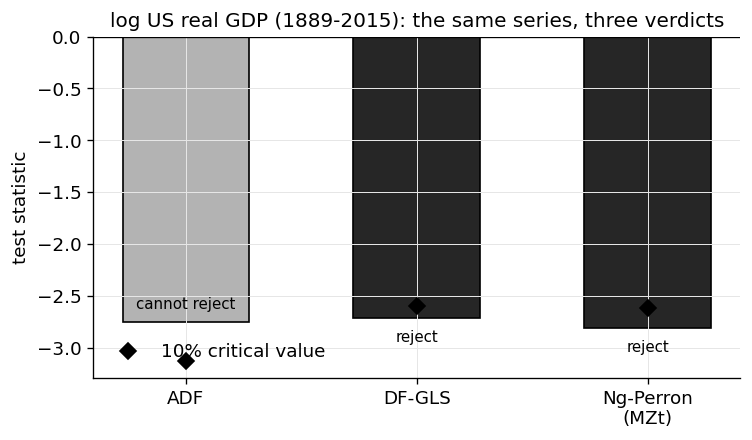

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
tests = ["ADF", "DF-GLS", "Ng-Perron\n(MZt)"]
stats = [adf_g["stat"], dfg_g["stat"], ngp_g["stat"]]
cv10 = [adf_g["crit_values"]["10%"], dfg_g["crit_values"]["10%"],
        ngp_g["crit_values"]["10%"]]
x = np.arange(3)
cols = ["0.15" if s < c else "0.7" for s, c in zip(stats, cv10)]
ax.bar(x, stats, color=cols, edgecolor="0.0", width=0.55)
ax.plot(x, cv10, "D", color="0.0", ms=7, label="10% critical value")
for xi, (s, c) in enumerate(zip(stats, cv10)):
    ax.annotate("reject" if s < c else "cannot reject", (xi, s),
                textcoords="offset points", xytext=(0, -14 if s < c else 8),
                ha="center", fontsize=9)
ax.axhline(0, color="0.0", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(tests)
ax.set_ylabel("test statistic")
ax.set_title("log US real GDP (1889-2015): the same series, three verdicts")
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

**Reading it.** All three statistics cluster near $-2.7$ — the *point
estimate* of persistence is identical. What differs is the yardstick: because
GLS detrending does not waste degrees of freedom fitting the trend against the
test, the DF-GLS / Ng-Perron 10% critical values ($\approx -2.6$) are less
demanding than ADF's ($\approx -3.1$), so the very same $-2.7$ clears the GLS
bar and misses the OLS bar. This is exactly the situation ERS designed for: a
root close enough to one that ADF is under-powered, but far enough that a
better test can see the mean reversion.

## The power gap, made explicit — a Monte Carlo

Is that one data point luck, or systematic higher power? Simulate
trend-stationary series $y_t = 0.05\,t + u_t$, $u_t = \phi u_{t-1}+\varepsilon_t$,
and count how often each test rejects the (false) unit-root null at 5% as
$\phi\to 1$. Under the alternative, *more rejections = more power*.

In [4]:
def _rejection_rates(phi, T=200, n_rep=300, seed0=0):
    adf_r = dfg_r = 0
    for r in range(n_rep):
        rng = np.random.default_rng(seed0 + r)
        u = np.zeros(T)
        for t in range(1, T):
            u[t] = phi * u[t - 1] + rng.standard_normal()
        y = 0.05 * np.arange(T) + u
        adf_r += adf_test(y, regression="ct")["p_value"] < 0.05
        dfg_r += dfgls_test(y, regression="ct")["p_value"] < 0.05
    return adf_r / n_rep, dfg_r / n_rep

PHIS = [0.80, 0.85, 0.90, 0.93, 0.95, 0.97]
adf_pow, dfg_pow = [], []
for phi in PHIS:
    a, d = _rejection_rates(phi)
    adf_pow.append(a); dfg_pow.append(d)
    print(f"  phi={phi:.2f}:  ADF power={a:.2f}   DF-GLS power={d:.2f}   "
          f"gain={d - a:+.2f}")

  phi=0.80:  ADF power=1.00   DF-GLS power=1.00   gain=+0.00
  phi=0.85:  ADF power=0.95   DF-GLS power=1.00   gain=+0.05
  phi=0.90:  ADF power=0.62   DF-GLS power=0.85   gain=+0.23
  phi=0.93:  ADF power=0.32   DF-GLS power=0.54   gain=+0.22


  phi=0.95:  ADF power=0.15   DF-GLS power=0.30   gain=+0.16

  phi=0.97:  ADF power=0.07   DF-GLS power=0.12   gain=+0.05


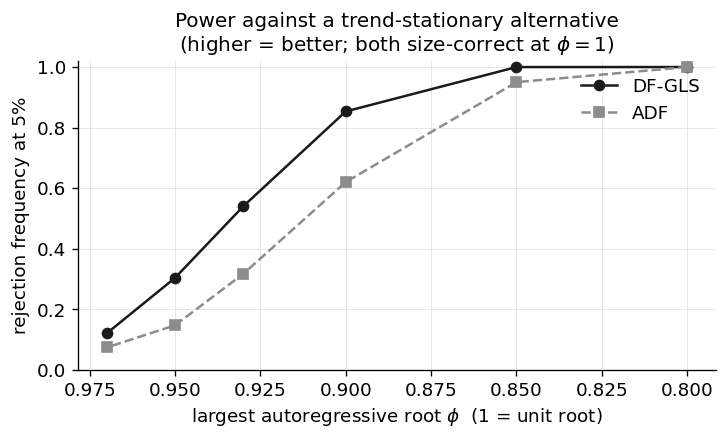

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(PHIS, dfg_pow, "-o", color="0.10", label="DF-GLS")
ax.plot(PHIS, adf_pow, "--s", color="0.55", label="ADF")
ax.set_xlabel(r"largest autoregressive root $\phi$  (1 = unit root)")
ax.set_ylabel("rejection frequency at 5%")
ax.set_title("Power against a trend-stationary alternative\n(higher = better; both size-correct at $\\phi=1$)")
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right")
ax.invert_xaxis()  # approaching the unit root from the left
plt.tight_layout(); plt.show()

**The selling point.** As $\phi$ climbs toward $1$ — precisely the region
where telling stationary from integrated is hard — DF-GLS keeps meaningful
power while ADF's collapses toward its size. The vertical gap between the
curves is the extra rejection probability GLS detrending buys, and it is
widest exactly where real macro series like output live. (At $\phi=1$ both
tests reject only ~5% of the time, confirming neither is over-sized — the gap
is genuine power, not a looser test.)

## A second series — the unemployment rate is mean-reverting

The unemployment rate has no trend but is highly persistent, so it is the
constant-case ($\bar c=-7$) analogue of the GDP debate. Here DF-GLS *and* ADF
both reject a unit root on the full 1948-2026 sample — and KPSS (whose null is
the opposite, *stationarity*) fails to reject — a coherent "persistent but
mean-reverting" verdict. The M-tests concur.

In [6]:
print("US unemployment rate, 1948-2026 (constant case, c-bar=-7):")
print(_fmt(adf_test(unrate, regression="c"), "ADF"))
print(_fmt(dfgls_test(unrate, regression="c"), "DF-GLS"))
print(_fmt(ng_perron_test(unrate, regression="c"), "Ng-Perron"), "(MZt)")
kp = kpss_test(unrate, regression="c")
print(f"  KPSS      stat={kp['stat']:.3f}  p={kp['p_value']:.3f}  "
      f"-> {kp['decision'].upper()} (H0=stationary; NOT rejecting = stationary)")
print("=> unit-root tests reject a unit root; KPSS does not reject stationarity:"
      " the rate mean-reverts.")

US unemployment rate, 1948-2026 (constant case, c-bar=-7):
  ADF       stat=-3.817  p=0.005  lag=0  CV(10%)=-2.57  -> REJECT
  DF-GLS    stat=-2.309  p=0.026  lag=0  CV(10%)=-1.62  -> REJECT
  Ng-Perron stat=-2.301  p=0.029  lag=0  CV(10%)=-1.62  -> REJECT (MZt)
  KPSS      stat=0.348  p=0.099  -> ACCEPT (H0=stationary; NOT rejecting = stationary)
=> unit-root tests reject a unit root; KPSS does not reject stationarity: the rate mean-reverts.


## Your turn — where does the extra power change the story?

The power gap only matters when a series sits in the ambiguous zone. Find one.

**Prompts.** (1) *Basic*: swap log real GDP for **log industrial production**
(`load_csv("okun")["indpro"]`, trend case) — both tests fail to reject there;
is the largest root simply too close to one for *any* test to help? (2)
*Intermediate*: re-run the GDP tests on **post-1947 subsamples** of `rz2018`;
as the window shrinks, ADF's power falls faster than DF-GLS's — plot the two
$p$-values against sample length. (3) *Stretch*: add a negative MA component
to the Monte Carlo DGP ($\varepsilon_t - 0.5\varepsilon_{t-1}$) and compare
ADF's *size* (rejection rate at $\phi=1$) with Ng-Perron's $MZ_t$ — this is the
size-distortion Ng & Perron (2001) built the M-tests to fix.

**How comprehensive is this?** `puremacro.tests.unit_root` ships `adf_test`,
`pp_test`, `kpss_test`, `zivot_andrews_test` (endogenous break), and now
`dfgls_test` + `ng_perron_test` (all four M-statistics with Ng-Perron 2001
critical values), sharing one MacKinnon-style critical-value/​p-value core —
so a full stationarity workflow (confirmatory ADF/DF-GLS + complementary KPSS
+ break-robust Zivot-Andrews) lives behind a single import.